In [119]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

df=pd.read_csv('Motorbike Adventure - Prophet.csv')

df.head()

,ds,y
0,2026-04-01 7:56:00,NaN
1,2026-04-01 8:01:00,60.0
2,2026-04-01 8:06:00,75.0
3,2026-04-01 8:11:00,130.0
4,2026-04-01 8:16:00,125.0


In [120]:
m = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    seasonality_mode='additive')

m.fit(df)

future = m.make_future_dataframe(periods=5760, freq='5min')

future = future[
    (future['ds'].dt.hour >= 8) &
    (future['ds'].dt.hour < 22) ]

13:10:20 - cmdstanpy - INFO - Chain [1] start processing
13:10:20 - cmdstanpy - INFO - Chain [1] done processing


In [121]:
df['floor'] = 0
future['floor'] = 0

forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
4867,2026-04-30 21:36:00,90.067389,-113.645720,313.499686
4868,2026-04-30 21:41:00,84.036596,-117.112362,307.896972
4869,2026-04-30 21:46:00,77.183677,-126.246219,302.150575
4870,2026-04-30 21:51:00,69.454416,-126.277154,290.159762
4871,2026-04-30 21:56:00,60.795338,-147.942323,285.430284


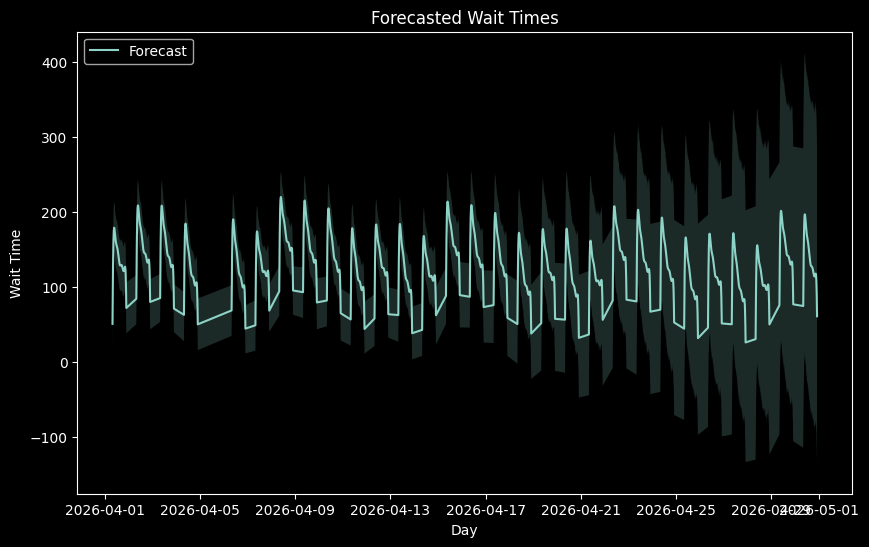

In [122]:
plt.figure(figsize=(10, 6))
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast')
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], alpha=0.2)
plt.title("Forecasted Wait Times")
plt.xlabel("Day")
plt.ylabel("Wait Time")
plt.legend()
plt.show()


In [127]:
import plotly.graph_objects as go
import plotly.offline as py
import plotly.io as pio

#Forecast
fore = go.Scatter(
    name="Forecast",
    x = forecast['ds'],
    y = forecast['yhat'],
    mode = 'lines',

    marker=dict(color="#7700B2"))

#Upper bound
upper_bound = go.Scatter(
    name = 'Upper Bound',
    mode = 'lines',
    x = forecast['ds'],
    y = forecast['yhat_upper'],
    marker=dict(color="#0072B2"),
    line=dict(width=.5),
    fill = 'tonexty')

#Lower bound
lower_bound = go.Scatter(
    name= 'Lower Bound',
    mode = 'lines',
    x = forecast['ds'],
    y = forecast['yhat_lower'],
    marker=dict(color="#0072B2"),
    line=dict(width=.5),)

traces = [fore, lower_bound, upper_bound]

layout = dict(title='Wait Time Forecast for Hagrid Motorbike Adventures',
             plot_bgcolor='white',
             hovermode='x',
             xaxis=dict(title = 'Date', ticklen=2, zeroline=True, linecolor='black', gridcolor='lightgrey', rangeslider=dict(visible=True)),
             yaxis=dict(title = 'Wait time', ticklen=2, zeroline=True, linecolor='black', gridcolor='lightgrey')
)

figure=dict(data=traces,layout=layout)
py.offline.iplot(figure)

fig = go.Figure(data=traces, layout=layout)

html_string = fig.to_html(full_html=False)

with open("plot_div.html", "w") as f:
    f.write(html_string)